# Performance Comparison of A2C and REINFORCE
## MountainCarContinuous-v0 | Team 4 | Hanbat National University

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")

## 1. Environment Exploration

In [3]:
env = gym.make("MountainCarContinuous-v0")
obs, _ = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = env.action_space.low[0]
action_high = env.action_space.high[0]
max_steps = env._max_episode_steps

In [4]:
print(f"State dimension  : {state_dim}")
print(f"Action dimension : {action_dim}")
print(f"Action range     : [{action_low}, {action_high}]")
print(f"Max steps        : {max_steps}")
print(f"Initial state    : {obs}")

State dimension  : 2
Action dimension : 1
Action range     : [-1.0, 1.0]
Max steps        : 999
Initial state    : [-0.4452088  0.       ]


### Random Agent Rollout

In [5]:
def random_rollout(env, seed=SEED):
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated, truncated = False, False

    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps

total_reward, steps = random_rollout(env)
print(f"Total reward : {total_reward:.2f}")
print(f"Steps taken  : {steps}")
print(f"Goal reached : {steps < 999}")

Total reward : -33.88
Steps taken  : 999
Goal reached : False


## 2. REINFORCE

In [6]:
# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.SELU(),
            nn.Linear(64, 64),
            nn.SELU(),
            nn.Linear(64, action_dim)
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, x: torch.Tensor):
        mean = torch.tanh(self.model(x))
        std = self.log_std.exp()
        return mean, std

    def act(self, state: torch.Tensor):
        mean, std = self.forward(state)
        pd = Normal(loc=mean, scale=std)
        action = pd.sample()
        log_prob = pd.log_prob(action)
        return action.clamp(-1.0, 1.0), log_prob

### Training Function

In [9]:
def train(policy, optimizer, log_probs, rewards, gamma):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    future_return = 0.0

    for t in reversed(range(T)):
        future_return = rewards[t] + gamma * future_return
        returns[t] = future_return

    returns = torch.tensor(returns)
    log_probs = torch.stack(log_probs)

    loss = -(log_probs * returns).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

### Training Loop

In [8]:
def train_reinforce(env, policy, optimizer, gamma, num_episodes):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        log_probs = []
        rewards = []
        terminated, truncated = False, False

        while not (terminated or truncated):
            state_tensor = torch.FloatTensor(state)
            action, log_prob = policy.act(state_tensor)
            action_np = action.detach().numpy()

            state, reward, terminated, truncated, _ = env.step(action_np)
            log_probs.append(log_prob)
            rewards.append(reward)

        train(policy, optimizer, log_probs, rewards, gamma)
        episode_rewards.append(sum(rewards))

        if (episode + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1} | Avg Reward (last 50): {avg:.2f}")

    return episode_rewards

### Hyperparameters and Training

In [61]:
GAMMA = 0.99
LR = 0.001
NUM_EPISODES = 1000

policy = PolicyNetwork(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=LR)

reinforce_rewards = train_reinforce(env, policy, optimizer, GAMMA, NUM_EPISODES)

Episode 50 | Avg Reward (last 50): -63.16
Episode 100 | Avg Reward (last 50): -66.18
Episode 150 | Avg Reward (last 50): -64.17
Episode 200 | Avg Reward (last 50): -67.33
Episode 250 | Avg Reward (last 50): -67.19
Episode 300 | Avg Reward (last 50): -67.16
Episode 350 | Avg Reward (last 50): -66.46
Episode 400 | Avg Reward (last 50): -66.82
Episode 450 | Avg Reward (last 50): -66.50
Episode 500 | Avg Reward (last 50): -67.22
Episode 550 | Avg Reward (last 50): -67.39
Episode 600 | Avg Reward (last 50): -67.53
Episode 650 | Avg Reward (last 50): -67.47
Episode 700 | Avg Reward (last 50): -67.57
Episode 750 | Avg Reward (last 50): -67.48
Episode 800 | Avg Reward (last 50): -67.78
Episode 850 | Avg Reward (last 50): -67.56
Episode 900 | Avg Reward (last 50): -67.83
Episode 950 | Avg Reward (last 50): -67.31
Episode 1000 | Avg Reward (last 50): -67.62


Episode 50 | Avg Reward (last 50): -48.73
Episode 100 | Avg Reward (last 50): -40.78
Episode 150 | Avg Reward (last 50): -55.10
Episode 200 | Avg Reward (last 50): -51.26
Episode 250 | Avg Reward (last 50): -51.85
Episode 300 | Avg Reward (last 50): -48.12
Episode 350 | Avg Reward (last 50): -55.17
Episode 400 | Avg Reward (last 50): -52.88
Episode 450 | Avg Reward (last 50): -50.29
Episode 500 | Avg Reward (last 50): -56.22
Episode 550 | Avg Reward (last 50): -50.87
Episode 600 | Avg Reward (last 50): -59.39
Episode 650 | Avg Reward (last 50): -44.44
Episode 700 | Avg Reward (last 50): -54.96
Episode 750 | Avg Reward (last 50): -57.80
Episode 800 | Avg Reward (last 50): -55.53
Episode 850 | Avg Reward (last 50): -61.30
Episode 900 | Avg Reward (last 50): -51.51
Episode 950 | Avg Reward (last 50): -48.63
Episode 1000 | Avg Reward (last 50): -47.68


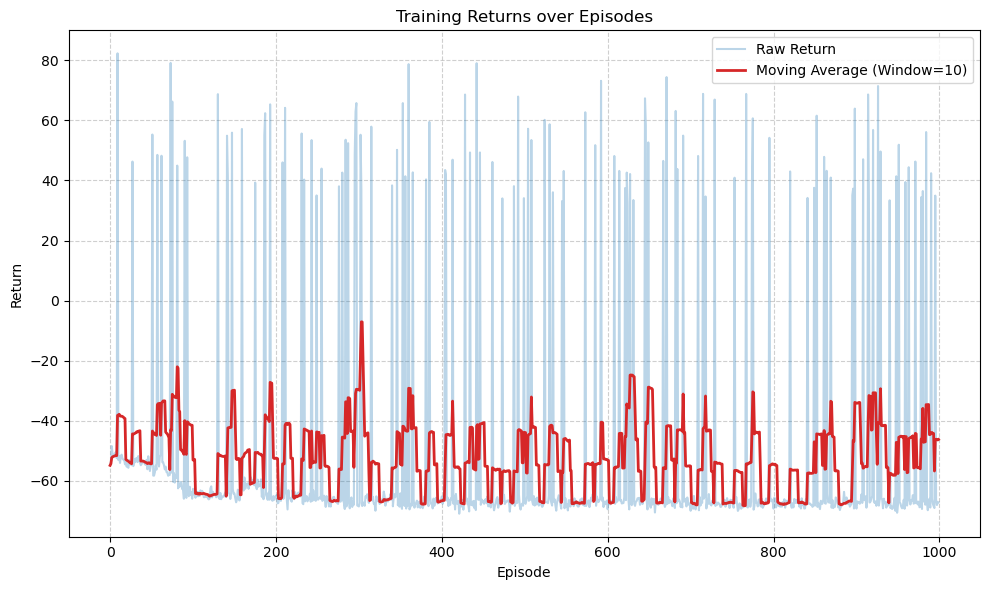

In [14]:
# train_reinforce(env, PolicyNetwork(state_dim, action_dim), optim.Adam(PolicyNetwork(state_dim, action_dim).parameters(), lr=0.001), gamma=0.95, num_episodes=500)

########### TRAINING AND VISUALIZING THE RESULTS

import matplotlib.pyplot as plt
import numpy as np

def plot_returns(rewards, window_size=10):
    # Calculate the moving average
    moving_avg = []
    for i in range(len(rewards)):
        # Use a shrinking window for the early episodes before window_size is reached
        start_idx = max(0, i - window_size + 1)
        moving_avg.append(np.mean(rewards[start_idx : i + 1]))

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot raw returns with lower opacity (alpha) so it doesn't clutter the graph
    plt.plot(rewards, color='tab:blue', alpha=0.3, label='Raw Return')

    # Plot moving average as a solid line
    plt.plot(moving_avg, color='tab:red', linewidth=2, label=f'Moving Average (Window={window_size})')

    plt.title('Training Returns over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    # Show the plot
    plt.show()


## Hyper parameters
GAMMA = 0.95
LR = 0.001
NUM_EPISODES = 1000

# 1. Instantiate the policy network ONCE and save it to a variable
policy = PolicyNetwork(state_dim, action_dim)

# 2. Pass the parameters of THAT EXACT policy to the optimizer
optimizer = optim.Adam(policy.parameters(), lr=LR)

# 3. Pass the policy, optimizer, and capture the returned rewards array
episode_rewards = train_reinforce(
    env=env,
    policy=policy,
    optimizer=optimizer,
    gamma=GAMMA,
    num_episodes=NUM_EPISODES
)

# 4. Plot the results
plot_returns(episode_rewards, window_size=10)

## 3. Advantage Actor-Critic (A2C)
### 3.1 Network Architecture

### Actor Network

In [15]:
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, x: torch.Tensor):
        x = torch.selu(self.fc1(x))
        x = torch.selu(self.fc2(x))
        mu = torch.tanh(self.mu(x))
        log_std = torch.clamp(self.log_std(x), -20, 2)
        std = torch.exp(log_std)
        return mu, std

### Critic Network

In [16]:
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor):
        x = torch.selu(self.fc1(x))
        x = torch.selu(self.fc2(x))
        return self.v(x)

### 3.2 Rollout Buffer

In [17]:
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

### 3.3 Agent

In [18]:
class Agent:
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic,
                 gamma=0.99, gae_lambda=0.95, entropy_coeff=0.2,
                 min_entropy_coeff=0.01, entropy_decay=0.995,
                 hidden_dim=64):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff
        self.min_entropy_coeff = min_entropy_coeff
        self.entropy_decay = entropy_decay

        self.actor = ActorNetwork(state_dim, action_dim, hidden_dim)
        self.critic = CriticNetwork(state_dim, hidden_dim)
        self.memory = RolloutBuffer()

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.exploration_noise = None
        self.reset_noise(action_dim)

    def reset_noise(self, action_dim=1):
        self.exploration_noise = torch.randn(action_dim)

    def decay_entropy(self):
        self.entropy_coeff = max(
            self.min_entropy_coeff,
            self.entropy_coeff * self.entropy_decay
        )

    def choose_action(self, state):
        state = torch.FloatTensor(state)
        mu, std = self.actor(state)
        raw_action = mu + std * self.exploration_noise
        action = torch.tanh(raw_action)
        dist = Normal(mu, std)
        log_prob = dist.log_prob(raw_action).sum()
        log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum()
        value = self.critic(state).squeeze()
        return action.detach().numpy(), log_prob, value

    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)

    def compute_returns_advantages(self, last_state, done):
        last_state = torch.FloatTensor(last_state)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values] + [next_value]

        returns = []
        advantages = []
        gae = 0.0

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t+1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = torch.tensor(returns, dtype=torch.float32)
        advantages = torch.tensor(advantages, dtype=torch.float32)
        advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = torch.FloatTensor(np.array(self.memory.states))
        actions = torch.FloatTensor(np.array(self.memory.actions))

        mu, std = self.actor(states)
        dist = Normal(mu, std)
        raw_actions = torch.atanh(torch.clamp(actions, -0.999, 0.999))
        log_probs = dist.log_prob(raw_actions).sum(dim=-1)
        log_probs -= torch.log(1 - actions.pow(2) + 1e-6).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze(-1)

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
        nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        self.memory.clear()

### 3.4 Training Loop

In [20]:
def train_a2c(env, agent, num_episodes, n_steps):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            action, log_prob, value = agent.choose_action(state)
            action_np = np.array(action, dtype=np.float32).reshape((1,))

            next_state, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated

            agent.store_transition(state, action, log_prob, reward, done, value)

            total_reward += reward
            step_count += 1
            state = next_state

            if step_count % 50 == 0:
                agent.reset_noise()

            if step_count % n_steps == 0:
                agent.learn(next_state, done)

        if not done:
            agent.learn(state, done)

        agent.decay_entropy()
        episode_rewards.append(total_reward)

        if (episode + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1} | Avg Reward (last 50): {avg:.2f}")

    return episode_rewards

### 3.5 Hyperparameters and Training

Episode 50 | Avg Reward (last 50): 80.05
Episode 100 | Avg Reward (last 50): 77.59
Episode 150 | Avg Reward (last 50): 73.56
Episode 200 | Avg Reward (last 50): 71.34
Episode 250 | Avg Reward (last 50): 73.58
Episode 300 | Avg Reward (last 50): 73.46
Episode 350 | Avg Reward (last 50): 75.70
Episode 400 | Avg Reward (last 50): 76.85
Episode 450 | Avg Reward (last 50): 75.15
Episode 500 | Avg Reward (last 50): 76.85
Episode 550 | Avg Reward (last 50): 66.48
Episode 600 | Avg Reward (last 50): 76.83
Episode 650 | Avg Reward (last 50): 75.75
Episode 700 | Avg Reward (last 50): 70.54
Episode 750 | Avg Reward (last 50): 77.94
Episode 800 | Avg Reward (last 50): 76.30
Episode 850 | Avg Reward (last 50): 72.30
Episode 900 | Avg Reward (last 50): 76.86
Episode 950 | Avg Reward (last 50): 75.35
Episode 1000 | Avg Reward (last 50): 73.90


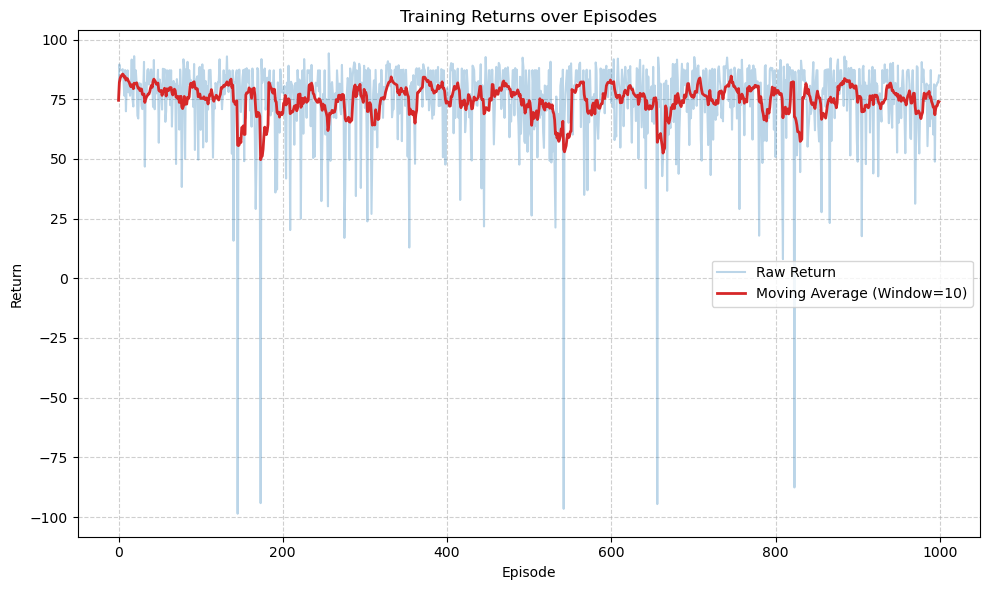

In [22]:
GAMMA = 0.95
LR_ACTOR = 0.0001 #5e-5
LR_CRITIC = 0.0001 #1e-4
ENTROPY_COEFF = 0.2
NUM_EPISODES = 1000
N_STEPS = 10
HIDDEN_DIM = 64

agent = Agent(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=LR_ACTOR,
    lr_critic=LR_CRITIC,
    gamma=GAMMA,
    gae_lambda=0.95,
    entropy_coeff=ENTROPY_COEFF,
    min_entropy_coeff=0.01,
    entropy_decay=0.995,
    hidden_dim=HIDDEN_DIM
)

a2c_rewards = train_a2c(env, agent, NUM_EPISODES, N_STEPS)

plot_returns(a2c_rewards, window_size=10)

#### Comparison between REINFORCE and A2C

In [23]:
def moving_average(rewards, window_size=10):
    moving_avg = []
    for i in range(len(rewards)):
        start_idx = max(0, i - window_size + 1)
        moving_avg.append(np.mean(rewards[start_idx:i + 1]))
    return np.array(moving_avg)


def plot_comparison(reinforce_rewards, a2c_rewards, window_size=10):
    plt.figure(figsize=(12, 6))

    # Episodes
    ep_reinforce = np.arange(len(reinforce_rewards))
    ep_a2c = np.arange(len(a2c_rewards))

    # Moving averages
    reinforce_ma = moving_average(reinforce_rewards, window_size)
    a2c_ma = moving_average(a2c_rewards, window_size)

    # Raw rewards
    plt.plot(
        ep_reinforce,
        reinforce_rewards,
        alpha=0.25,
        linewidth=1,
        label="REINFORCE (raw)"
    )

    plt.plot(
        ep_a2c,
        a2c_rewards,
        alpha=0.25,
        linewidth=1,
        label="A2C (raw)"
    )

    # Moving averages
    plt.plot(
        ep_reinforce,
        reinforce_ma,
        linewidth=2.5,
        label=f"REINFORCE ({window_size}-ep avg)"
    )

    plt.plot(
        ep_a2c,
        a2c_ma,
        linewidth=2.5,
        label=f"A2C ({window_size}-ep avg)"
    )

    plt.title("REINFORCE vs A2C on MountainCarContinuous-v0")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

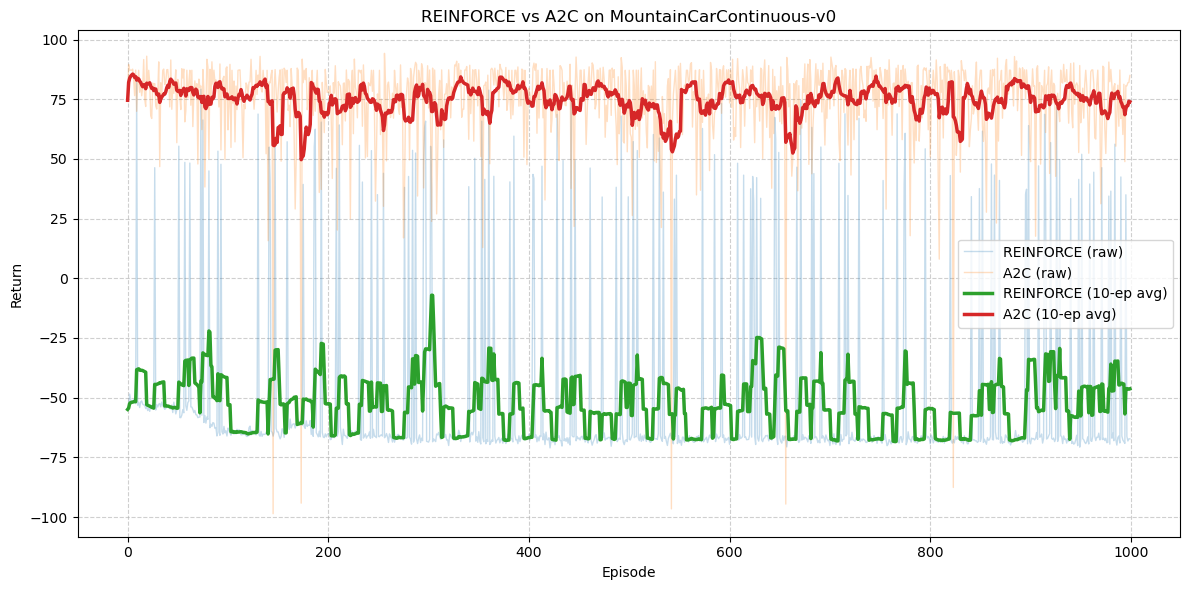

In [24]:
plot_comparison(
    reinforce_rewards=episode_rewards,
    a2c_rewards=a2c_rewards,
    window_size=10
)